In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.knowledge_distillation2 as kd_agent
import configurations.config_eval_kd2 as config
import algorithms.d3qn_lstm_rep_bh_gae_dual as model

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(kd_agent)
importlib.reload(config)
importlib.reload(model)

device used:  cuda
device used:  cuda


<module 'algorithms.d3qn_lstm_rep_bh_gae_dual' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\algorithms\\d3qn_lstm_rep_bh_gae_dual.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.knowledge_distillation2 import KnowledgeDistillationAgent
from configurations.config_eval_kd2 import config
from algorithms.d3qn_lstm_rep_bh_gae_dual import KnowledgeNet

In [5]:
print(config)

{'seed': 333, 'gamma': 0.99, 'bufferSize': 1000000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimLR': 0.0001, 'MAX_TRAIN_EPISODES': 500, 'MAX_EVAL_EPISODES': 5, 'explorationStrategyTrainFn': <function selectEpsilonGreedyActionREP_NOISY at 0x0000017700F49580>, 'explorationStrategyEvalFn': <function selectGreedyActionREP_COMP at 0x0000017700F49440>, 'max_steps': 1000, 'epsilon': 0.98, 'eps_decay_strategy': [('linear', {'s': 0, 'e': 200, 'ival': 1.0, 'fval': 0.3}), ('exponential', {'s': 201, 'e': 499, 'ival': 0.3, 'fval': 0.02})], 'device': device(type='cuda'), 'beta': 0.3, 'f_hDim': [324, 256], 'lstm_hDim': 128, 'model_path': '../model_weights/model_weights_eval_kd2', 'seq_len': 40, 'burn_in': 10, 'minSamples': 40, 'for_hDim': [224, 128], 'inv_hDim': [224, 128], 'noise_std': 0.05, 'clip_eps': 0.2, 'entropy_coef': 0.01, 'forward_coef': 0.1, 'inverse_coef': 0.04, 'action_dim': 5, 'state_dim': 18, 'tau': 0.2, 'updateTargetFrequency': 20, 'kl_coef': 0.12, 'gae_lambd

In [6]:
env1 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)

env2 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=3,
    box_speed=4,
)

teachers_path = f'{config['model_path']}/teachers'
teachers = []
for i in range(4):
    model = KnowledgeNet(
        f_hDim=[324, 256],
        lstm_hDim=128,
        for_hDim=[224, 128],
        inv_hDim=[224, 128]
    )
    wpath = f"{teachers_path}/model{i+1}.pth"
    model.load_state_dict(torch.load(wpath, map_location="cpu"))
    teachers.append(model)

KD_PPO_Agent = KnowledgeDistillationAgent(env1, env2, teachers, config)

In [7]:
(kdTrainRewardList, kdTrainTimeList, kdEvalRewardsList1, 
kdEvalRewardsList2, kdWallClockTimeList, kdTotalStepsList,
klList, entropyList, lossList) = KD_PPO_Agent.runKDAgent()

Episode 1: TR(with walls) -33979.000 | TT 7.522 | TS 1000
Episode 2: TR(with walls) -15471.000 | TT 15.129 | TS 1000
Episode 3: TR(without walls) -22051.000 | TT 21.486 | TS 783
Episode 4: TR(with walls) 2066.000 | TT 21.934 | TS 55
Episode 5: TR(without walls) -45967.000 | TT 30.118 | TS 1000
Episode 6: TR(with walls) -48080.000 | TT 38.288 | TS 1000
Episode 7: TR(with walls) -31068.000 | TT 46.381 | TS 1000
Episode 8: TR(without walls) -15069.000 | TT 54.461 | TS 1000
Episode 9: TR(with walls) -27167.000 | TT 62.227 | TS 1000
Episode 10: TR(with walls) 2082.000 | TT 62.634 | TS 48
Episode 11: TR(with walls) -52385.000 | TT 70.956 | TS 1000
Episode 12: TR(with walls) -79286.000 | TT 78.664 | TS 1000
Episode 13: TR(without walls) -13962.000 | TT 81.493 | TS 292
Episode 14: TR(without walls) -30779.000 | TT 97.817 | TS 1000
Episode 15: TR(with walls) -22570.000 | TT 113.390 | TS 1000
Episode 16: TR(without walls) -48197.000 | TT 129.400 | TS 1000
Episode 17: TR(with walls) -33274.000 | 

In [8]:
results = {
    "train_rewards": kdTrainRewardList,
    "train_time": kdTrainTimeList,
    "eval_rewards_env1": kdEvalRewardsList1,
    "eval_rewards_env2": kdEvalRewardsList2,
    "wall_clock_time": kdWallClockTimeList,
    "total_steps": kdTotalStepsList,
    "kl": klList,
    "entropy": entropyList,
    "loss": lossList
}

save_path = f"{config['model_path']}/kd_results1.pt"
torch.save(results, save_path)

print(f"Saved results to {save_path}")

Saved results to ../model_weights/model_weights_eval_kd2/kd_results1.pt


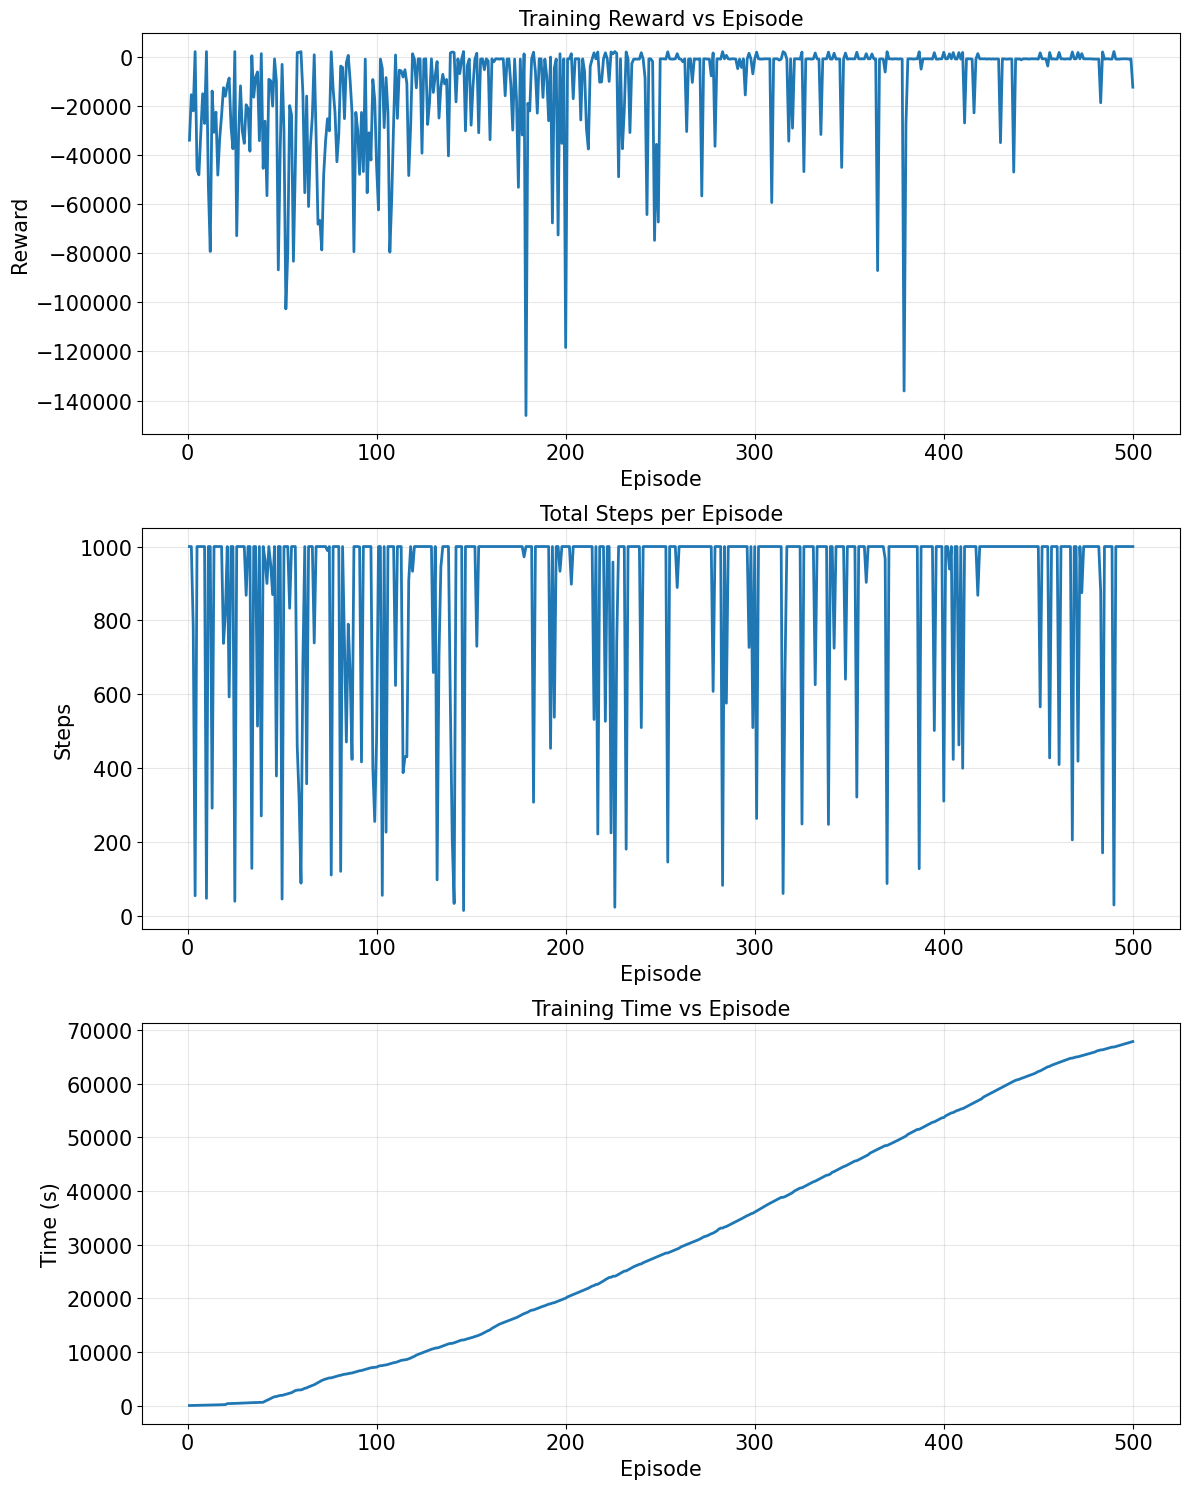

In [9]:
import matplotlib.pyplot as plt
import numpy as np

episodes = np.arange(1, len(kdTrainRewardList) + 1)

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Global style tuning
title_size = 15
label_size = 15
tick_size = 15

# Training Reward
axes[0].plot(episodes, kdTrainRewardList, linewidth=2)
axes[0].set_title("Training Reward vs Episode", fontsize=title_size)
axes[0].set_xlabel("Episode", fontsize=label_size)
axes[0].set_ylabel("Reward", fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].grid(alpha=0.3)

# Total Steps
axes[1].plot(episodes, kdTotalStepsList, linewidth=2)
axes[1].set_title("Total Steps per Episode", fontsize=title_size)
axes[1].set_xlabel("Episode", fontsize=label_size)
axes[1].set_ylabel("Steps", fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)
axes[1].grid(alpha=0.3)

# Training Time
axes[2].plot(episodes, kdTrainTimeList, linewidth=2)
axes[2].set_title("Training Time vs Episode", fontsize=title_size)
axes[2].set_xlabel("Episode", fontsize=label_size)
axes[2].set_ylabel("Time (s)", fontsize=label_size)
axes[2].tick_params(axis='both', labelsize=tick_size)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

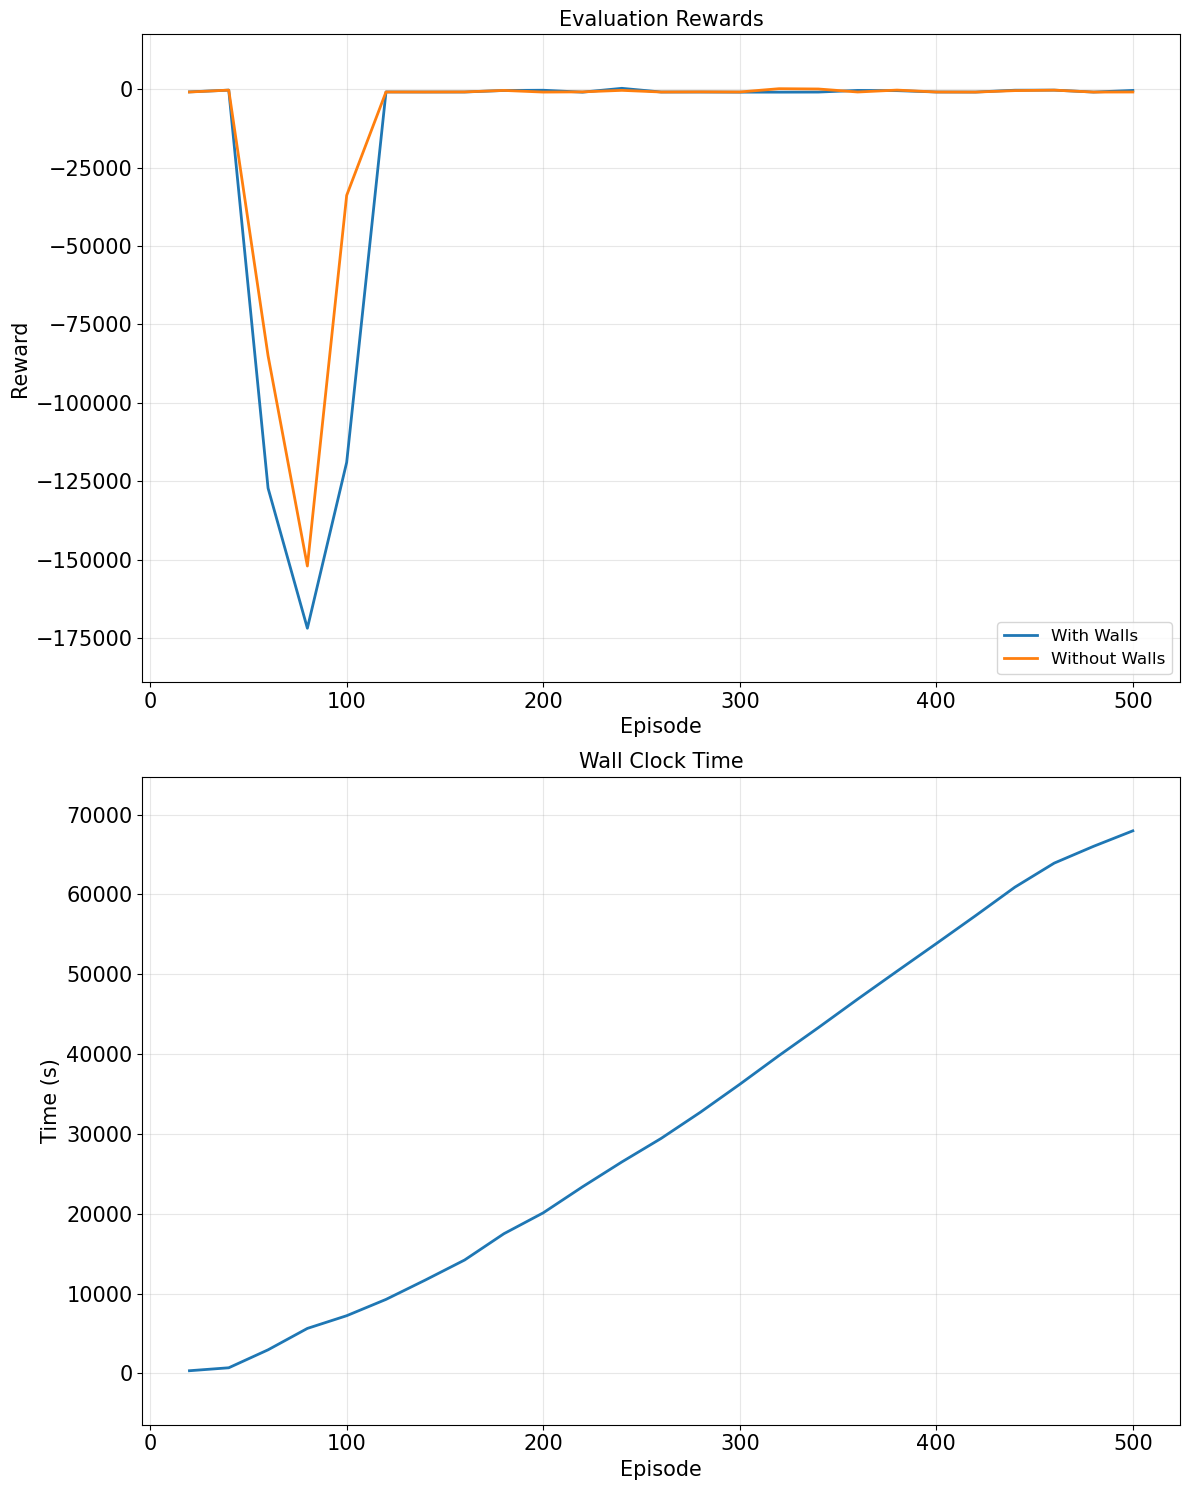

In [10]:
eval_episodes = np.arange(20, 20 * len(kdEvalRewardsList1) + 1, 20)

fig, axes = plt.subplots(2, 1, figsize=(12, 15))

# Evaluation Rewards
axes[0].plot(eval_episodes, kdEvalRewardsList1, linewidth=2, label="With Walls")
axes[0].plot(eval_episodes, kdEvalRewardsList2, linewidth=2, label="Without Walls")
axes[0].set_title("Evaluation Rewards", fontsize=title_size)
axes[0].set_xlabel("Episode", fontsize=label_size)
axes[0].set_ylabel("Reward", fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].margins(y=0.1)

# Wall Clock Time
axes[1].plot(eval_episodes, kdWallClockTimeList, linewidth=2)
axes[1].set_title("Wall Clock Time", fontsize=title_size)
axes[1].set_xlabel("Episode", fontsize=label_size)
axes[1].set_ylabel("Time (s)", fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)
axes[1].grid(alpha=0.3)
axes[1].margins(y=0.1)

plt.subplots_adjust(hspace=0.35)
plt.tight_layout()
plt.show()

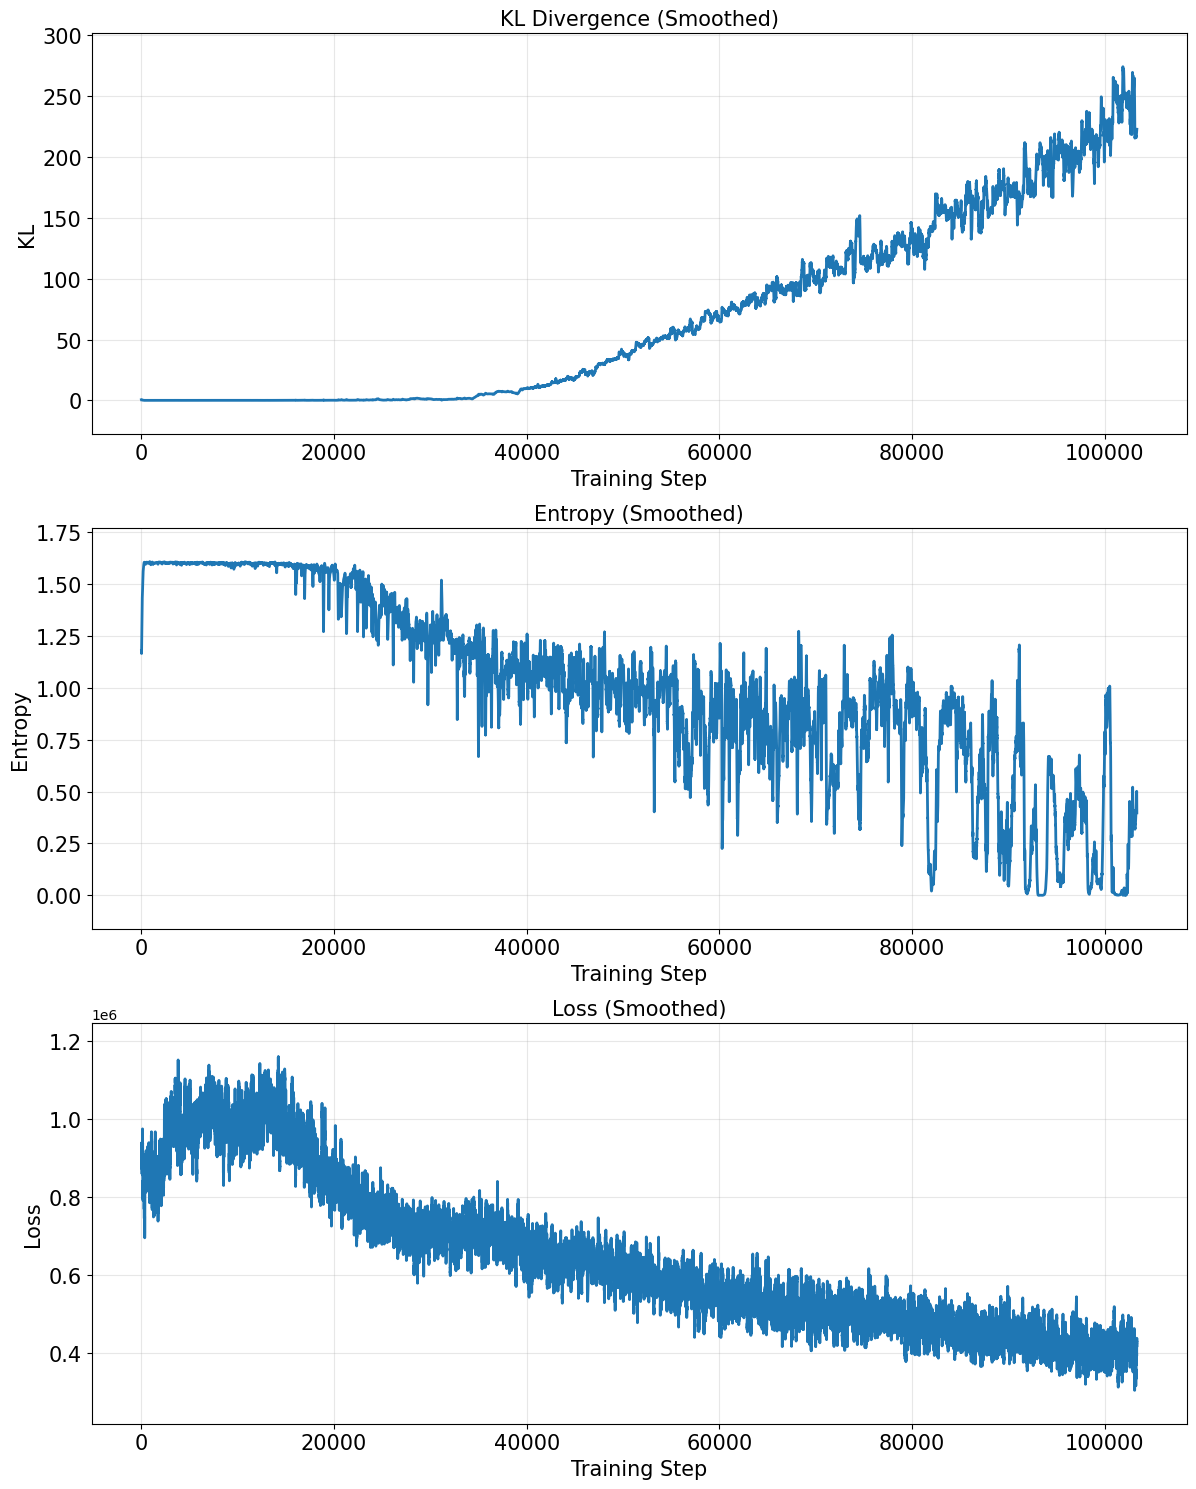

In [11]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# KL
axes[0].plot(smooth(klList), linewidth=2)
axes[0].set_title("KL Divergence (Smoothed)", fontsize=title_size)
axes[0].set_xlabel("Training Step", fontsize=label_size)
axes[0].set_ylabel("KL", fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].grid(alpha=0.3)
axes[0].margins(y=0.1)

# Entropy
axes[1].plot(smooth(entropyList), linewidth=2)
axes[1].set_title("Entropy (Smoothed)", fontsize=title_size)
axes[1].set_xlabel("Training Step", fontsize=label_size)
axes[1].set_ylabel("Entropy", fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)
axes[1].grid(alpha=0.3)
axes[1].margins(y=0.1)

# Loss
axes[2].plot(smooth(lossList), linewidth=2)
axes[2].set_title("Loss (Smoothed)", fontsize=title_size)
axes[2].set_xlabel("Training Step", fontsize=label_size)
axes[2].set_ylabel("Loss", fontsize=label_size)
axes[2].tick_params(axis='both', labelsize=tick_size)
axes[2].grid(alpha=0.3)
axes[2].margins(y=0.1)

plt.subplots_adjust(hspace=0.35)
plt.tight_layout()
plt.show()